In [7]:
import os
import sys
import pandas as pd
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# --- Configuration ---
# Update these paths to match your local folders if needed
CSV_PATH = r"C:\Users\My Computer\Desktop\sentiment analysis\TRAIN.csv"
AUDIO_DIR = r"C:\Users\My Computer\Desktop\sentiment analysis\TRAIN"

# Audio Hyperparameters
SAMPLE_RATE = 22050
DURATION = 3
N_MELS = 64
NUM_SAMPLES = int(SAMPLE_RATE * DURATION)
HOP_LENGTH = 512
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.001

# Check for GPU (RTX 5060 Ti)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

🚀 Using Device: cuda


In [8]:
class AudioDataset(Dataset):
    def __init__(self, csv_file, audio_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.audio_dir = audio_dir
        
        # Verify columns (Case Insensitive)
        if 'Class' not in self.df.columns and 'class' in self.df.columns:
            self.df.rename(columns={'class': 'Class'}, inplace=True)
            
        # Encode Labels
        self.le = LabelEncoder()
        self.df['label_encoded'] = self.le.fit_transform(self.df['Class'])
        
        # Save Label Encoder for the App later
        with open('label_encoder.pkl', 'wb') as f:
            pickle.dump(self.le, f)
        print(f"✅ Classes Found: {self.le.classes_}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get file path and label
        filename = str(self.df.iloc[idx]['Filename'])
        label = self.df.iloc[idx]['label_encoded']
        file_path = os.path.join(self.audio_dir, filename)

        # Load and process audio
        try:
            signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            
            # Pad or Truncate to ensure fixed length
            if len(signal) > NUM_SAMPLES:
                signal = signal[:NUM_SAMPLES]
            else:
                padding = NUM_SAMPLES - len(signal)
                signal = np.pad(signal, (0, padding), mode='constant')

            # Extract Mel Spectrogram
            mel_spec = librosa.feature.melspectrogram(
                y=signal, sr=SAMPLE_RATE, n_mels=N_MELS, hop_length=HOP_LENGTH
            )
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            
            # Normalize to 0-1
            norm_spec = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-6)
            
            # Convert to PyTorch Tensor: (Channels, Freq, Time)
            spec_tensor = torch.tensor(norm_spec, dtype=torch.float32).unsqueeze(0)
            
            return spec_tensor, torch.tensor(label, dtype=torch.long)
            
        except Exception as e:
            print(f"Error loading {filename}: {e}")
            # Return dummy tensor to prevent crash
            return torch.zeros((1, N_MELS, 129)), torch.tensor(0, dtype=torch.long)

In [9]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super(AudioCNN, self).__init__()
        
        # Convolutional Blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(16)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(32)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(64)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(128)
        )
        
        # Dense Layers
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

In [10]:
# Prepare Data
print("⏳ Preparing Dataset...")
full_dataset = AudioDataset(CSV_PATH, AUDIO_DIR)
train_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True)

num_classes = len(full_dataset.le.classes_)

# Initialize Model, Loss, Optimizer
model = AudioCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("🏋️ Starting Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Stats
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {running_loss/len(train_loader):.4f} | Accuracy: {100 * correct / total:.2f}%")

# Save Model
print("💾 Saving PyTorch Model...")
torch.save(model.state_dict(), 'audio_sentiment_model.pth')
print(f"✅ Model saved to: {os.path.abspath('audio_sentiment_model.pth')}")

⏳ Preparing Dataset...
✅ Classes Found: ['Negative' 'Neutral' 'Positive']
🏋️ Starting Training...
Epoch [1/10] Loss: 0.7244 | Accuracy: 74.00%
Epoch [2/10] Loss: 0.4422 | Accuracy: 79.60%
Epoch [3/10] Loss: 0.2799 | Accuracy: 90.80%
Epoch [4/10] Loss: 0.1844 | Accuracy: 94.80%
Epoch [5/10] Loss: 0.1996 | Accuracy: 91.60%
Epoch [6/10] Loss: 0.1228 | Accuracy: 95.20%
Epoch [7/10] Loss: 0.0632 | Accuracy: 98.40%
Epoch [8/10] Loss: 0.0711 | Accuracy: 97.60%
Epoch [9/10] Loss: 0.0367 | Accuracy: 99.20%
Epoch [10/10] Loss: 0.0601 | Accuracy: 98.80%
💾 Saving PyTorch Model...
✅ Model saved to: c:\Users\My Computer\Desktop\sentiment analysis\audio_sentiment_model.pth


🔍 Running Evaluation...

🏆 Overall Test Accuracy: 98.80%

📜 Classification Report:
              precision    recall  f1-score   support

    Negative       0.97      1.00      0.98        87
     Neutral       1.00      1.00      1.00        81
    Positive       1.00      0.96      0.98        82

    accuracy                           0.99       250
   macro avg       0.99      0.99      0.99       250
weighted avg       0.99      0.99      0.99       250



Text(0.5, 1.0, 'Confusion Matrix')

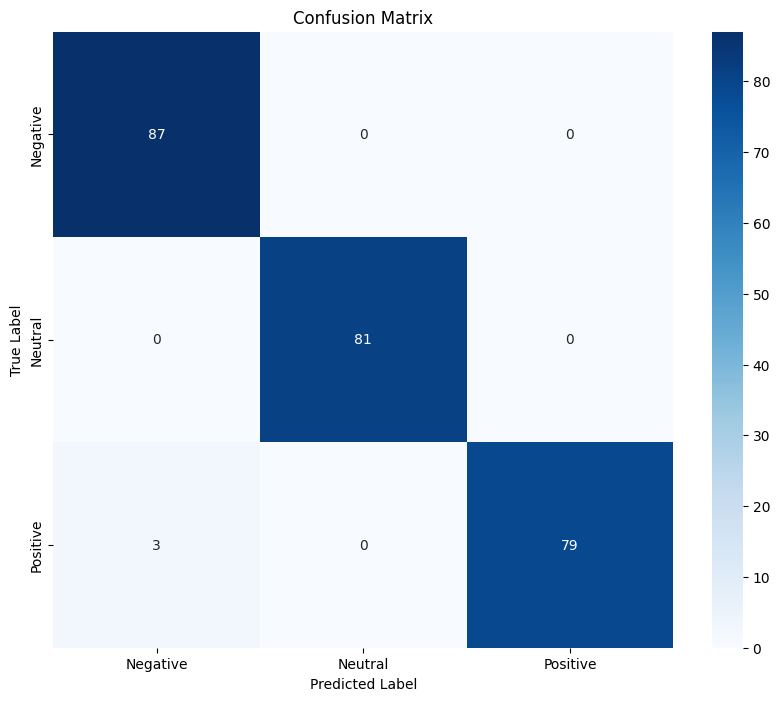

In [13]:
# --- IMPORTANT: Keep this line ---
%matplotlib inline 

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Run Predictions ---
print("🔍 Running Evaluation...")
model.eval()

all_preds = []
all_labels = []

# Use a non-shuffled loader for evaluation
eval_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for inputs, labels in eval_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- 2. Metrics ---
accuracy = accuracy_score(all_labels, all_preds)
print(f"\n🏆 Overall Test Accuracy: {accuracy * 100:.2f}%")
print("\n📜 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.le.classes_))

# --- 3. Plot Confusion Matrix ---
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

# Adding a semicolon ';' at the end suppresses extra text output
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=full_dataset.le.classes_, 
            yticklabels=full_dataset.le.classes_);

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Removed plt.show() to prevent double plotting